# Lab Experiment 5: Linear Regression through Gradient Descent

**Aim:** Implement linear regression with batch gradient descent and evaluate it on the Student Performance dataset.

The target is the final mathematics grade (`G3`).

In [6]:
# Importing necessary libraries and loading data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = 'student/student-mat.csv'

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Dataset shape: {df.shape}')
display(df.head())
print(f'Total missing values: {df.isna().sum().sum()}')

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Total missing values: 0


## 2. Select features, split, and preprocess

Numeric variables are median-imputed and standardized. Categorical variables are mode-imputed and one-hot encoded. The transformations are fitted **only on the training set**, so test-set information does not influence training.

In [7]:
target = 'G3'
leakage_columns = ['G1', 'G2']
X = df.drop(columns=[target, *leakage_columns])
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f'Original input features: {X.shape[1]}')
print(f'Training shape after preprocessing: {X_train_processed.shape}')
print(f'Testing shape after preprocessing:  {X_test_processed.shape}')

Original input features: 30
Training shape after preprocessing: (316, 56)
Testing shape after preprocessing:  (79, 56)


## 3. Linear regression implemented with batch gradient descent

For MSE loss, the gradients are $\frac{2}{n}X^T(\hat y-y)$ for the weights and $2\,\mathrm{mean}(\hat y-y)$ for the bias.

In [8]:
class LinearRegressionGradientDescent:
    def __init__(self, learning_rate=0.01, n_iterations=3000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            predictions = X @ self.weights + self.bias
            errors = predictions - y
            self.loss_history.append(np.mean(errors ** 2))
            self.weights -= self.learning_rate * (2 / n_samples) * (X.T @ errors)
            self.bias -= self.learning_rate * 2 * errors.mean()
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.weights + self.bias

## 4. Compare learning rates and inspect convergence

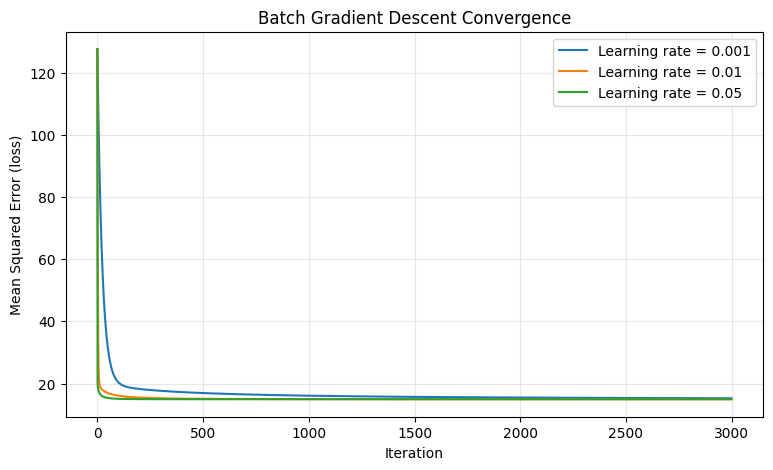

,Learning rate,Initial loss,Final loss
0,0.001,127.6297,15.2477
1,0.010,127.6297,14.9393
2,0.050,127.6297,14.9390


In [9]:
learning_rates = [0.001, 0.01, 0.05]
models = {}

plt.figure(figsize=(9, 5))
for learning_rate in learning_rates:
    model = LinearRegressionGradientDescent(learning_rate=learning_rate, n_iterations=3000)
    model.fit(X_train_processed, y_train)
    models[learning_rate] = model
    plt.plot(model.loss_history, label=f'Learning rate = {learning_rate}')

plt.title('Batch Gradient Descent Convergence')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (loss)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

loss_summary = pd.DataFrame({
    'Learning rate': learning_rates,
    'Initial loss': [models[lr].loss_history[0] for lr in learning_rates],
    'Final loss': [models[lr].loss_history[-1] for lr in learning_rates]
})
display(loss_summary.round(4))

## 5. Evaluate the best converged model

The learning rate with the lowest final training loss is chosen, then evaluated once on the untouched test set.

In [10]:
best_learning_rate = min(models, key=lambda lr: models[lr].loss_history[-1])
best_model = models[best_learning_rate]
y_pred = best_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})
display(metrics.round(4))
print(f'Selected learning rate: {best_learning_rate}')
print(f'Final training loss: {best_model.loss_history[-1]:.4f}')

,Metric,Value
0,MAE,3.3953
1,MSE,17.6037
2,RMSE,4.1957
3,R² Score,0.1415


Selected learning rate: 0.05
Final training loss: 14.9390


## 6. Interpretation

A decreasing loss curve that flattens indicates stable convergence. A very small learning rate usually converges slowly; a larger stable rate reaches a low loss faster. MAE and RMSE report typical error in grade points (lower is better), while R² reports the fraction of variation in `G3` explained by the selected features. Since `G1` and `G2` were excluded, the result reflects prediction from background, school, family, and study-related information rather than earlier grades.